In [2]:

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize,square,dilation
import os
import pathlib
import sys
from matplotlib.colors import ListedColormap



Ce code est repris de l'exemple disponible ici : [https://pvbm.readthedocs.io/en/latest/](https://pvbm.readthedocs.io/en/latest/).  

Le problème avec nos données actuelles est de pouvoir récupérer le **squelette des vaisseaux** avec une bonne qualité et sans erreurs.  
Cela permettrait de continuer l'exécution de ce code **sans problème**.  

Actuellement, le code télécharge les images de test, mais le squelette est déjà construit dans une autre image.  

La première étape serait donc de **récupérer le cercle indiquant la zone susceptible de poser problème**, afin d'aider au minimum les médecins.


In [3]:
path_to_save_datasets = "../PVBM_datasets"

In [4]:
from PVBM.Datasets import PVBMDataDownloader
dataset_downloader = PVBMDataDownloader()
dataset_downloader.download_dataset(name="Crop_HRF", save_folder_path=path_to_save_datasets)
dataset_downloader.download_dataset(name="INSPIRE", save_folder_path=path_to_save_datasets)
dataset_downloader.download_dataset(name="UNAF", save_folder_path=path_to_save_datasets)
print("Images downloaded successfully")



Downloading...
From (original): https://drive.google.com/uc?id=1QcozuK5yDyXbBkHqkbM5bxEkTGzkPDl3
From (redirected): https://drive.google.com/uc?id=1QcozuK5yDyXbBkHqkbM5bxEkTGzkPDl3&confirm=t&uuid=b210a16d-fa90-40a4-affe-fc8b8e171499
To: /home/merry251/Documents/Master_projet/eye/Crop_HRF.zip
100%|██████████| 42.0M/42.0M [00:01<00:00, 23.8MB/s]


Dataset downloaded and saved to Crop_HRF.zip
Files extracted to ../PVBM_datasets
Deleted the zip file: Crop_HRF.zip


Downloading...
From (original): https://drive.google.com/uc?id=18TcmkuN_eZgM2Ph5XiX8x7_ejtKhA3qb
From (redirected): https://drive.google.com/uc?id=18TcmkuN_eZgM2Ph5XiX8x7_ejtKhA3qb&confirm=t&uuid=0e69fe79-e520-454a-a056-11bfa5918ee5
To: /home/merry251/Documents/Master_projet/eye/INSPIRE.zip
100%|██████████| 29.6M/29.6M [00:00<00:00, 55.8MB/s]


Dataset downloaded and saved to INSPIRE.zip
Files extracted to ../PVBM_datasets
Deleted the zip file: INSPIRE.zip


Downloading...
From: https://drive.google.com/uc?id=1IM5qUEARNp2RFpzKmILbdgasjLuJEIcX
To: /home/merry251/Documents/Master_projet/eye/UNAF.zip
100%|██████████| 19.7M/19.7M [00:00<00:00, 23.8MB/s]


Dataset downloaded and saved to UNAF.zip
Files extracted to ../PVBM_datasets
Deleted the zip file: UNAF.zip
Images downloaded successfully


In [5]:
segmentation_path = list(pathlib.Path(path_to_save_datasets).glob("INSPIRE/artery/*"))[0]
segmentation_path

PosixPath('../PVBM_datasets/INSPIRE/artery/image24.png')

In [6]:
segmentation = Image.open(segmentation_path) #Open the segmentation

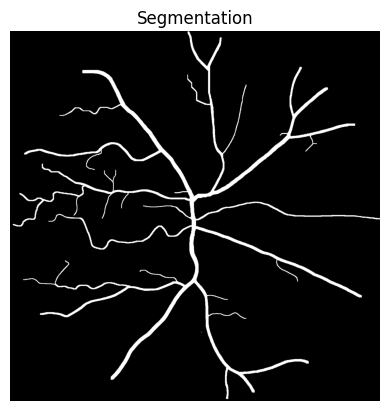

In [7]:
plt.imshow(segmentation,cmap = "gray") #Display the segmentation
plt.title("Segmentation")
plt.axis('off')
plt.show()

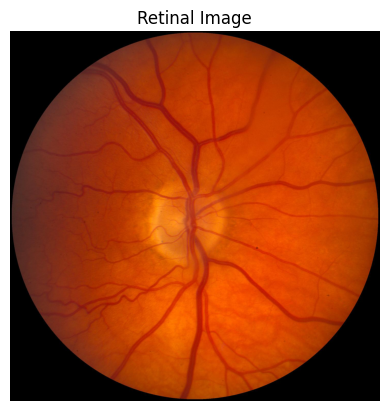

In [8]:
image_path = str(segmentation_path).replace("artery","images").replace("veins", "images")
image = Image.open(image_path)
plt.imshow(image) #Display the segmentation
plt.title("Retinal Image")
plt.axis('off')
plt.show()



In [9]:
segmentation = np.array(segmentation)/255 #Convert the segmentation to a numpy array with value 0 and 1
skeleton = skeletonize(segmentation)*1 #Compute the skeleton of the segmentation


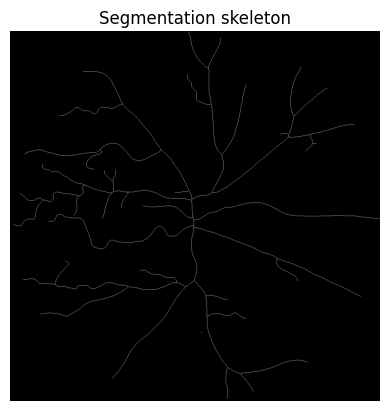

In [10]:
plt.imshow(skeleton,cmap = 'gray')
plt.title("Segmentation skeleton")
plt.axis('off')
plt.show()

In [11]:
from PVBM.DiscSegmenter import DiscSegmenter
segmenter = DiscSegmenter()


Model path: /home/merry251/Documents/recherche/envi/venv/lib/python3.12/site-packages/PVBM/lunetv2_odc.onnx
Model already exists, skipping download.


In [12]:
optic_disc = segmenter.segment(image_path=str(segmentation_path).replace("artery","images").replace("veins", "images"))

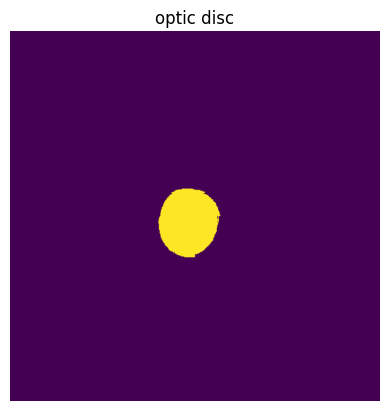

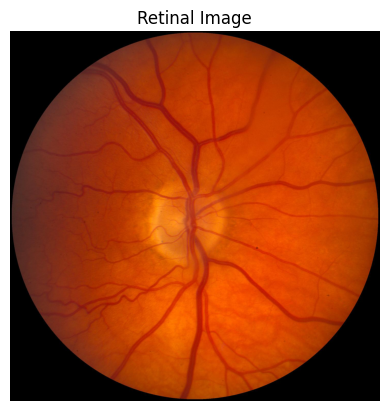

In [13]:
plt.imshow(optic_disc)
plt.title("optic disc")
plt.axis('off')
plt.show()
plt.imshow(image)
plt.title("Retinal Image")
plt.axis('off')
plt.show()

In [14]:
center, radius, roi, zones_ABC = segmenter.post_processing(segmentation=optic_disc, max_roi_size=600)

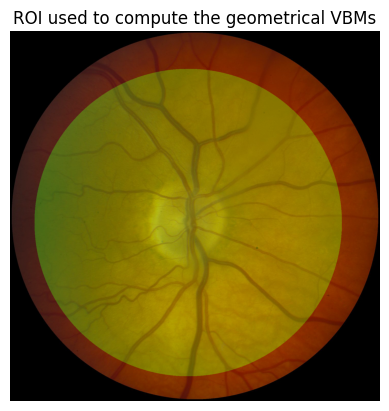

In [15]:
plt.imshow(image)
plt.imshow(roi, alpha = 0.3)
plt.title("ROI used to compute the geometrical VBMs")
plt.axis('off')
plt.show()



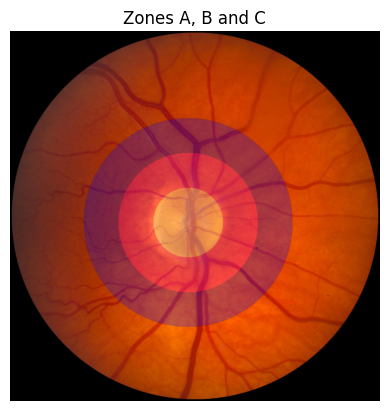

In [16]:
plt.imshow(image)
plt.imshow(zones_ABC/255, alpha = 0.5)
plt.title("Zones A, B and C")
plt.axis('off')
plt.show()

In [17]:
from PVBM.GeometryAnalysis import GeometricalVBMs #Import the geometry analysis module
geometricalVBMs = GeometricalVBMs()

In [18]:


segmentation_roi, skeleton_roi = geometricalVBMs.apply_roi(
    segmentation=segmentation,
    skeleton=skeleton,
    zones_ABC=zones_ABC,
    roi=roi
)



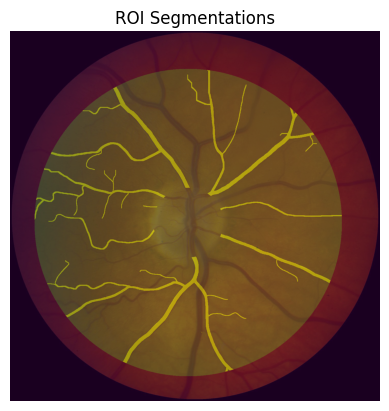

In [19]:
plt.imshow(image)
plt.imshow(segmentation_roi, alpha = 0.5)
plt.imshow(roi, alpha = 0.2)
plt.title("ROI Segmentations") #Segmentation within the ROI that will be used for the geometrical VBMs
plt.axis('off')
plt.show()

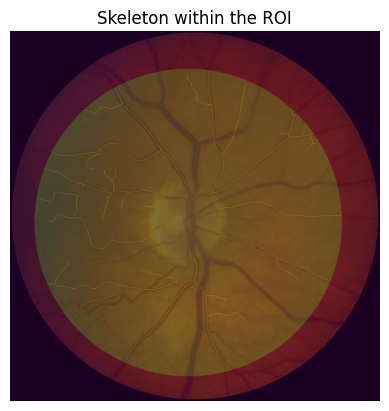

In [20]:
plt.imshow(image)
plt.imshow(skeleton_roi, alpha = 0.5)
plt.imshow(roi, alpha = 0.2)
plt.title("Skeleton within the ROI") #that will be used for the geometrical VBMs
plt.axis('off')
plt.show()

In [21]:
vbms, visual = geometricalVBMs.compute_geomVBMs(
    blood_vessel=segmentation_roi,
    skeleton=skeleton_roi,
    xc=center[0],
    yc=center[1],
    radius=radius
)



In [22]:
area, TI, medTor, ovlen, medianba, startp, endp, interp = vbms
area, TI, medTor, ovlen, medianba, startp, endp, interp
print(f"\n Area : {area} \n Tortuosity Index: {TI} \n Median Tortuosity: {medTor}\n Overall Length {ovlen} \n Median Branching angles {medianba}\n Number of Start/End/Intersection points {startp}/ {endp} / {interp}")




 Area : 67961.0 
 Tortuosity Index: 1.1175146259517241 
 Median Tortuosity: 1.0849056710685532
 Overall Length 8266.288306652797 
 Median Branching angles 77.30817217296718
 Number of Start/End/Intersection points 8/ 31.0 / 27.0


In [23]:
endpoints, interpoints, startpoints, angles_dico, topology_dico = visual

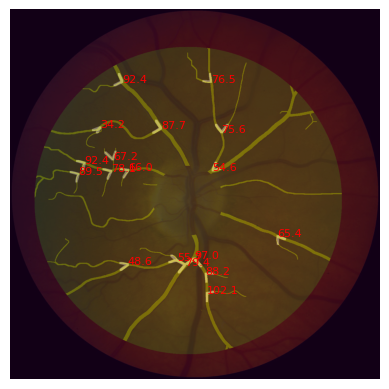

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.draw import line_aa
from scipy.ndimage import binary_dilation


def display_angles(angles_dico, img):
    for key, value in angles_dico.items():
        b = key
        if len(value) == 2:
            a, c = value
            if all(x is not None for x in (a, b, c)):
                ba = np.array(a) - np.array(b)
                bc = np.array(c) - np.array(b)
                cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
                angle = np.arccos(cosine_angle)
                rr, cc, val = line_aa(b[0], b[1], a[0], a[1])
                img[rr, cc] = val * 255
                rr, cc, val = line_aa(b[0], b[1], c[0], c[1])
                img[rr, cc] = val * 255
                plt.text(b[1], b[0], f"{np.degrees(angle):.1f}", color='red', fontsize=8)
        elif len(value) == 3:
            a, c, d = value
            if all(x is not None for x in (a, b, c, d)):
                # First angle (a-b-c)
                ba = np.array(a) - np.array(b)
                bc = np.array(c) - np.array(b)
                cosine_angle_ac = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
                angle_ac = np.arccos(cosine_angle_ac)
                rr, cc, val = line_aa(b[0], b[1], a[0], a[1])
                img[rr, cc] = val * 255
                rr, cc, val = line_aa(b[0], b[1], c[0], c[1])
                img[rr, cc] = val * 255
                plt.text(b[1], b[0], f"{np.degrees(angle_ac):.1f}", color='red', fontsize=8)

                # Second angle (c-b-d)
                bc = np.array(c) - np.array(b)
                bd = np.array(d) - np.array(b)
                cosine_angle_cd = np.dot(bc, bd) / (np.linalg.norm(bc) * np.linalg.norm(bd))
                angle_cd = np.arccos(cosine_angle_cd)
                rr, cc, val = line_aa(b[0], b[1], c[0], c[1])
                img[rr, cc] = val * 255
                rr, cc, val = line_aa(b[0], b[1], d[0], d[1])
                img[rr, cc] = val * 255
                plt.text(b[1], b[0] + 10, f"{np.degrees(angle_cd):.1f}", color='red', fontsize=8)

img = np.zeros_like(segmentation)

display_angles(angles_dico, img)

# Dilate the image
img_dilated = binary_dilation(img, structure=np.ones((8,8))) * 255

plt.imshow(image)
plt.imshow(segmentation_roi, alpha = 0.5)
plt.imshow(roi, alpha = 0.2)
plt.imshow(img_dilated, cmap='gray', alpha = 0.3)
plt.axis('off')
plt.show()

/tmp/ipykernel_93022/1119079870.py:4: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  plt.imshow(segmentation/50+dilation(endpoints, square(15)), alpha = 0.5)


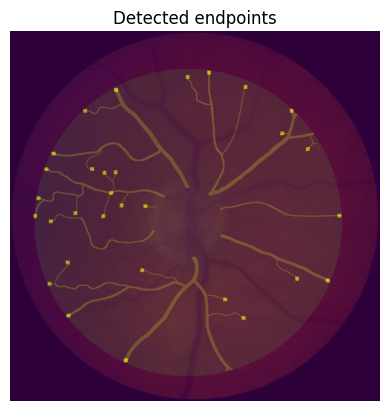

In [25]:
plt.imshow(image)
plt.imshow(segmentation_roi, alpha = 0.5)
plt.imshow(roi, alpha = 0.2)
plt.imshow(segmentation/50+dilation(endpoints, square(15)), alpha = 0.5)
plt.title("Detected endpoints")
plt.axis('off')
plt.show()

/tmp/ipykernel_93022/3364056745.py:4: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  plt.imshow(segmentation/20+dilation(interpoints, square(15)), alpha = 0.5)


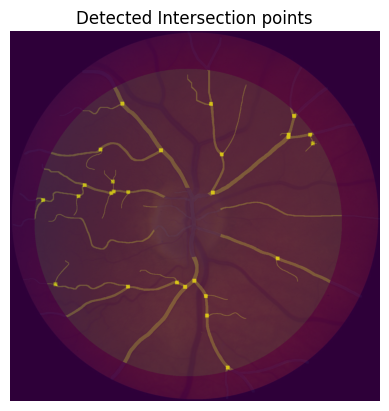

In [26]:


plt.imshow(image)
plt.imshow(segmentation_roi, alpha = 0.5)
plt.imshow(roi, alpha = 0.2)
plt.imshow(segmentation/20+dilation(interpoints, square(15)), alpha = 0.5)
plt.title("Detected Intersection points")
plt.axis('off')
plt.show()



/tmp/ipykernel_93022/2269999439.py:4: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  plt.imshow(segmentation/20+dilation(startpoints, square(15)), alpha = 0.5)


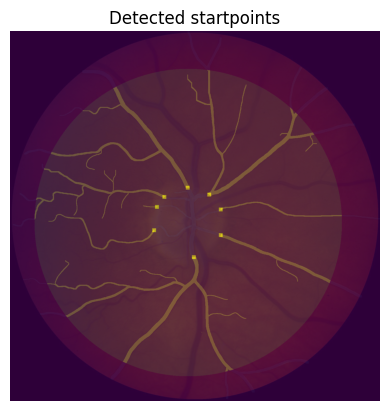

In [27]:
plt.imshow(image)
plt.imshow(segmentation_roi, alpha = 0.5)
plt.imshow(roi, alpha = 0.2)
plt.imshow(segmentation/20+dilation(startpoints, square(15)), alpha = 0.5)
plt.title("Detected startpoints")
plt.axis('off')
plt.show()

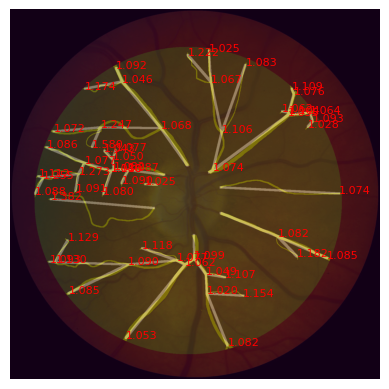

In [28]:
from skimage.draw import line_aa
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import binary_dilation

img = np.zeros_like(segmentation)

for key, value in topology_dico.items():
        rr, cc, val = line_aa(key[0], key[1], key[2], key[3])
        img[rr, cc] = val * 255
        plt.text(key[3], key[2], f"{value[0]/value[1]:.3f}", color='red', fontsize=8)

# Dilate the image
img_dilated = binary_dilation(img, structure=np.ones((8,8))) * 255

plt.imshow(image)
plt.imshow(segmentation_roi, alpha = 0.5)
plt.imshow(roi, alpha = 0.2)
plt.imshow(img_dilated, cmap='gray', alpha = 0.3)
plt.axis('off')
plt.show()

In [29]:
from PVBM.FractalAnalysis import MultifractalVBMs
fractalVBMs = MultifractalVBMs(n_rotations = 25,optimize = True, min_proba = 0.0001, maxproba = 0.9999)

In [30]:
D0,D1,D2,SL = fractalVBMs.compute_multifractals(segmentation_roi.copy())

In [31]:
print("The fractal biomarkers are D0: {}, D1: {}, D2: {}, SL: {}".format(D0,D1,D2,SL))

The fractal biomarkers are D0: 1.3548388558757765, D1: 1.332185362648519, D2: 1.3178386288856296, SL: 0.8345694310427461


In [32]:
from PVBM.CentralRetinalAnalysis import CREVBMs
creVBMs = CREVBMs()

In [33]:
segmentation_roi, skeleton_roi = creVBMs.apply_roi(
    segmentation=segmentation,
    skeleton=skeleton,
    zones_ABC=zones_ABC
)

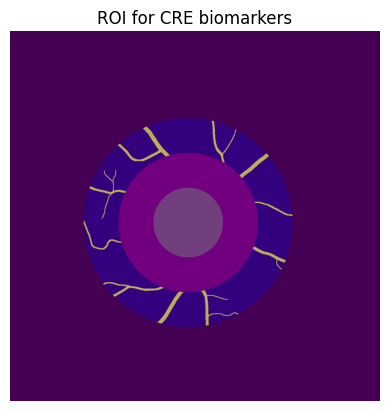

In [34]:
plt.imshow(segmentation_roi)
plt.imshow(zones_ABC/255, alpha = 0.5)
plt.axis('off')
plt.title("ROI for CRE biomarkers")
plt.show()



In [35]:
plot = True

In [36]:
out = creVBMs.compute_central_retinal_equivalents(
    blood_vessel=segmentation_roi.copy(),
    skeleton=skeleton_roi.copy(),
    xc=center[0],
    yc=center[1],
    radius=radius,
    artery = True,
    Toplot = plot
)



/home/merry251/Documents/recherche/envi/venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/merry251/Documents/recherche/envi/venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/merry251/Documents/recherche/envi/venv/lib/python3.12/site-packages/PVBM/GraphCRE/GraphCentralRetinalEquivalent.py:128: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  tmp2[:, :, 3] = dilation(p, square(3))
/home/merry251/Documents/recherche/envi/venv/lib/python3.12/site-packages/PVBM/GraphCRE/GraphCentralRetinalEquivalent.py:129: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  tmp2[:, :, 1] = d

In [37]:
if out == -1:
    raise ValueError("The CRE computation failed")
else:
    output, visualisation = out
    print(output)


{'craek': 22.28228212053942, 'craeh': 24.348159170274336}


In [38]:
if plot:
    # Load all the logs to build the cre visualisation
    measurements = [item['plot'] for item in visualisation]
    # Compute the aggregated visualisation
    measurements = np.maximum.reduce(measurements)



/tmp/ipykernel_93022/1527860214.py:27: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  plt.imshow(dilation(startpoints_cre, square(15)), alpha = 0.5)


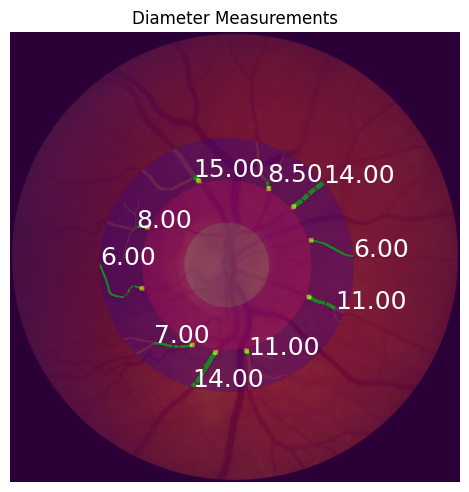

In [39]:
if plot:

    # Create a new figure
    plt.imshow(image)
    plt.imshow(segmentation_roi, alpha = 0.3)
    plt.imshow(zones_ABC/255, alpha = 0.5)
    plt.imshow(measurements)


    startpoints_cre = np.zeros((segmentation_roi.shape[0], segmentation_roi.shape[1]))

    # Annotate the image with 'Mean diameter' from each dictionary
    for item in visualisation:

        startpoints_cre[item["start"]] = 1
        # Get the 'end' location and 'Mean diameter'
        end_location = item['end']  # Assuming 'end' is a tuple (x, y)
        mean_diameter = "{:.2f}".format(item['Median diameter'])

        # Annotate the image
        plt.annotate(mean_diameter,
                     (end_location[1], end_location[0]),
                     color='white',
                     fontsize=18)

    # Display the combined image
    plt.imshow(dilation(startpoints_cre, square(15)), alpha = 0.5)

    plt.axis('off')
    plt.tight_layout()
    plt.title("Diameter Measurements")
    plt.show()